# Digital Twin EDS

Use the digital twin to acquire a simulated image, place the beam, and collect an EDS spectrum.

## Start the digital twin servers

Open a terminal from the repository root and run:

```bash
uv run scripts/run_servers.py --microscope dt
```

Choose the same Tango host/port that this notebook uses below (`10.46.217.241:9094` by default), or update `DB_HOST` and `DB_PORT` in the ping cell to match your server. The digital twin does not require AutoScript hardware; the DATA/Tiled server is started from the notebook after the Tango devices are running.


### Imports


In [1]:
import os
import json
import time

import tango
import numpy as np
import matplotlib.pyplot as plt
from tiled.client import from_uri

%matplotlib ipympl


### Ping servers


In [2]:
DB_HOST = '127.0.0.1' #"10.46.217.241"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'microscope']

for name in server_names:
    device_name = f"asyncroscopy/{name}/default"
    proxy = tango.DeviceProxy(device_name)
    proxy.ping()
    print(device_name, proxy.state())


asyncroscopy/stage/default ON
asyncroscopy/scan/default ON
asyncroscopy/eds/default ON
asyncroscopy/camera/default ON
asyncroscopy/data/default ON
asyncroscopy/microscope/default ON


### Connect to devices


In [3]:
scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/microscope/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

# Backward-compatible aliases used by the workflow cells below.
mic_proxy = microscope
microscope_proxy = microscope

for proxy in (scan, microscope, data):
    proxy.set_timeout_millis(120_000)

print("scan      :", scan.state())
print("microscope:", microscope.state())
print("data      :", data.state())


scan      : ON
microscope: ON
data      : ON


### Start Tiled data server


In [4]:
TILED_HOST = '127.0.0.1' #"10.46.217.241"
TILED_PORT = 9091
save_path = '/Users/austin/Desktop/example'

data.host = TILED_HOST
data.port = TILED_PORT
data.save_path = save_path

if str(data.tiled_server).lower() != "yes":
    print("Tiled server is not responding; starting it from the DATA device...")
    config = json.loads(data.start_tiled_server())
else:
    print("Tiled server is already running.")
    config = json.loads(data.get_config())

print(json.dumps(config, indent=2))

client = from_uri(config.get("uri", f"http://{TILED_HOST}:{TILED_PORT}"))
print("Tiled keys:", list(client))


Tiled server is not responding; starting it from the DATA device...
{
  "host": "127.0.0.1",
  "port": 9091,
  "uri": "http://127.0.0.1:9091",
  "save_path": "/Users/austin/Desktop/example",
  "tiled_server": "yes",
  "tiled_server_status": "running; watcher started"
}
Tiled keys: []


### Acquire a simulated HAADF image


Tiled key: stem_image_HAADF_20260527T131546668900.tiff
Metadata : {'ImageWidth': 512, 'ImageLength': 512, 'BitsPerSample': 32, 'Compression': 1, 'PhotometricInterpretation': 1, 'ImageDescription': '{"acquisition_type": "stem_image", "detector": "HAADF", "dwell_time": 1e-06, "shape": [512, 512], "dtype": "float32", "simulation_backend": "DigitalTwin", "stage_position": [0.0, 0.0, 0.0, 0.0, 0.0], "beam_position": [0.5, 0.5], "fov_m": 2e-08, "fov_angstrom": 200.0, "imsize": 512, "sample_seed": 12345, "sample_size_xy": 6e-09, "sample_size_z": 6e-09, "viewport_world_angstrom": {"x_min": -100.0, "x_max": 100.0, "y_min": -100.0, "y_max": 100.0, "z_center": 0.0}, "world_bounds_angstrom": {"x_min": -30.0, "x_max": 30.0, "y_min": -30.0, "y_max": 30.0, "z_min": -30.0, "z_max": 30.0}, "particle_count": 3}', 'StripOffsets': [760], 'RowsPerStrip': 512, 'StripByteCounts': [1048576], 'PlanarConfiguration': 1, 'SampleFormat': 3}


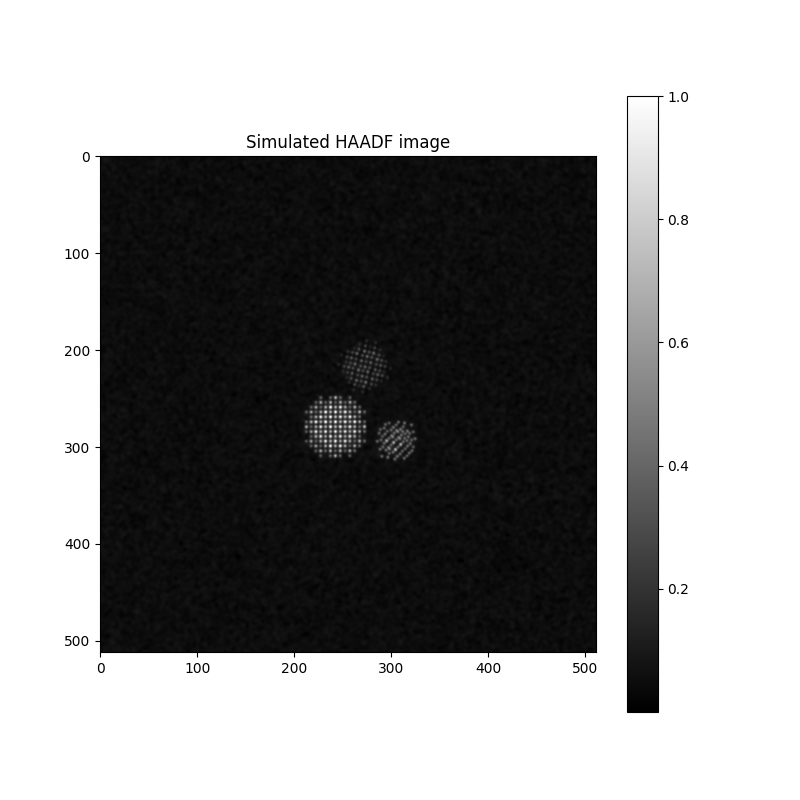

In [7]:
key = microscope.get_scanned_image()
node = client[key]
image = np.asarray(node.read())
metadata = dict(node.metadata)

print("Tiled key:", key)
print("Metadata :", metadata)

plt.figure(figsize=(8, 8))
plt.imshow(image.T, cmap="gray")
plt.title("Simulated HAADF image")
plt.colorbar()
plt.show()


### Place the beam


In [ ]:
mic_proxy.place_beam([0.46, 0.65])

### Query the beam position


In [ ]:
beam_pos = mic_proxy.beam_pos

In [ ]:
# Read beam position and scale from fractional [0,1] to pixel coordinates
beam_pos = mic_proxy.beam_pos                  # returns [x, y] in [0.0, 1.0]
h, w = image.shape
beam_x_px = beam_pos[0] * w                   # fractional → pixel
beam_y_px = beam_pos[1] * h

plt.figure(figsize=(8, 8))
plt.imshow(image.T, cmap='gray')

# Overlay beam position
plt.scatter(beam_x_px, beam_y_px, 
            color='red', s=100, marker='+',
            linewidths=2, label="Beam position")

plt.title(f"Simulated {meta['detector']} image")
plt.legend(loc='upper right')
plt.colorbar()
plt.show()

### Acquire a simulated EDS spectrum


In [ ]:
key = microscope.get_spectrum("eds")
node = client[key]["spectrum"]
spectrum = np.squeeze(np.asarray(node.read()))
metadata = dict(node.metadata)

print("Tiled key     :", key)
print("Metadata      :", metadata)
print("Spectrum shape:", spectrum.shape)
spectrum
